# 06 — Temperature sweep (−40 °C … +125 °C)

Models applied to the analytical path:

- $R(T)=R_0\bigl(1+\mathrm{TCR}\cdot 10^{-6}(T-25)\bigr)$
- $C(T)=C_0\bigl(1+\mathrm{TCC}\cdot 10^{-6}(T-25)\bigr)$
- $V_{OS}(T)=V_{OS,25}+\alpha_{V_{OS}}(T-25)$
- $|I_B|(T)$ scaled by an empirical CMOS growth factor

SPICE: `.temp` plus the same passive scaling (ideal model recommended for fair compare).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
# Operating point overrides
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}


,temp_c,R1,R2,R3,C1,C2,C3,vos,ibp,fc_hz,passband_gain,gain_at_fdesign,phase_at_fdesign_deg,dc_error
0,-40.0,1794.15,19436.625,149512.5,3.293565e-09,4.690835e-11,2.195710e-10,-0.000065,1.777433e-13,19872.354802,0.999993,0.703593,-100.368753,0.000065
1,-30.0,1795.05,19446.375,149587.5,3.294555e-09,4.692245e-11,2.196370e-10,-0.000055,3.304120e-13,19855.966868,0.999993,0.703142,-100.444602,0.000055
2,-20.0,1795.95,19456.125,149662.5,3.295545e-09,4.693655e-11,2.197030e-10,-0.000045,6.142121e-13,19839.628488,0.999993,0.702690,-100.520456,0.000045
3,-10.0,1796.85,19465.875,149737.5,3.296535e-09,4.695065e-11,2.197690e-10,-0.000035,1.141776e-12,19823.339445,0.999993,0.702238,-100.596315,0.000035
4,0.0,1797.75,19475.625,149812.5,3.297525e-09,4.696475e-11,2.198350e-10,-0.000025,2.122480e-12,19807.099520,0.999993,0.701785,-100.672179,0.000025


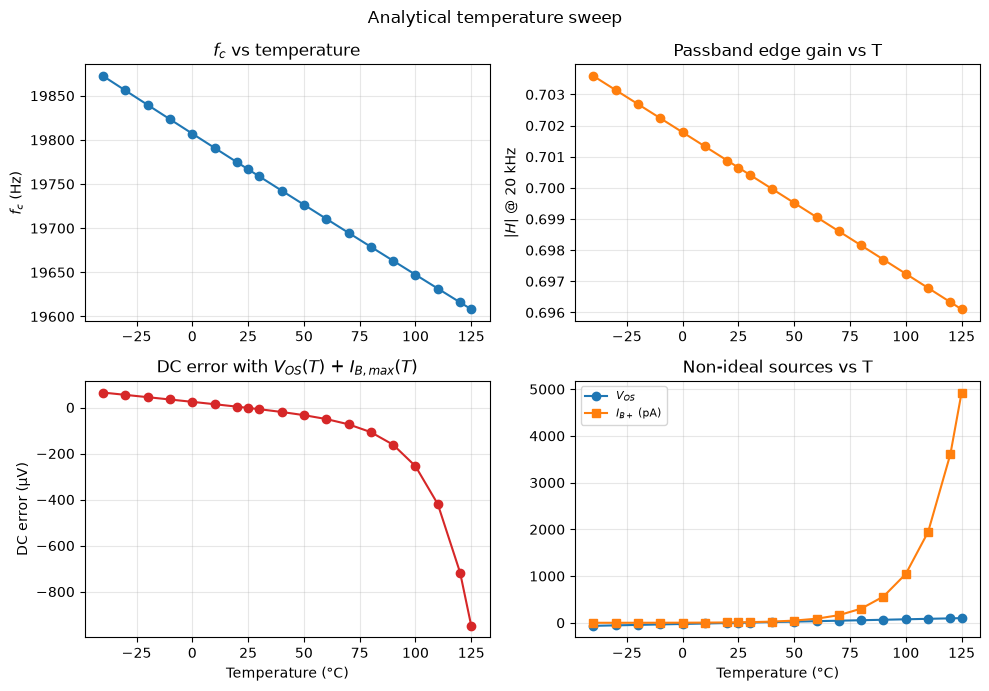

In [2]:
from opamp_design.temperature import sweep_analytical, spice_temp_sweep

# Optional tempco overrides:
# p = replace(p, tempco=replace(p.tempco, tcr_ppm_per_c=50, tcc_ppm_per_c=30))

ts = sweep_analytical(p, vos_25=0.0, use_ib_max_at_temp=True)
ts.save(ROOT / "results" / "temp_analytical.csv")
display(ts.frame.head())

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
df = ts.frame
axes[0, 0].plot(df.temp_c, df.fc_hz, "o-")
axes[0, 0].set_ylabel(r"$f_c$ (Hz)")
axes[0, 0].set_title(r"$f_c$ vs temperature")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df.temp_c, df.gain_at_fdesign, "o-", color="C1")
axes[0, 1].set_ylabel(r"$|H|$ @ 20 kHz")
axes[0, 1].set_title("Passband edge gain vs T")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df.temp_c, df.dc_error * 1e6, "o-", color="C3")
axes[1, 0].set_ylabel(r"DC error (µV)")
axes[1, 0].set_xlabel("Temperature (°C)")
axes[1, 0].set_title(r"DC error with $V_{OS}(T)$ + $I_{B,max}(T)$")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df.temp_c, df.vos * 1e6, "o-", label=r"$V_{OS}$")
axes[1, 1].plot(df.temp_c, df.ibp * 1e12, "s-", label=r"$I_{B+}$ (pA)")
axes[1, 1].set_xlabel("Temperature (°C)")
axes[1, 1].set_title("Non-ideal sources vs T")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
fig.suptitle("Analytical temperature sweep")
fig.tight_layout()
fig.savefig(FIG / "06_temp_sweep_analytical.png", dpi=150)
plt.show()

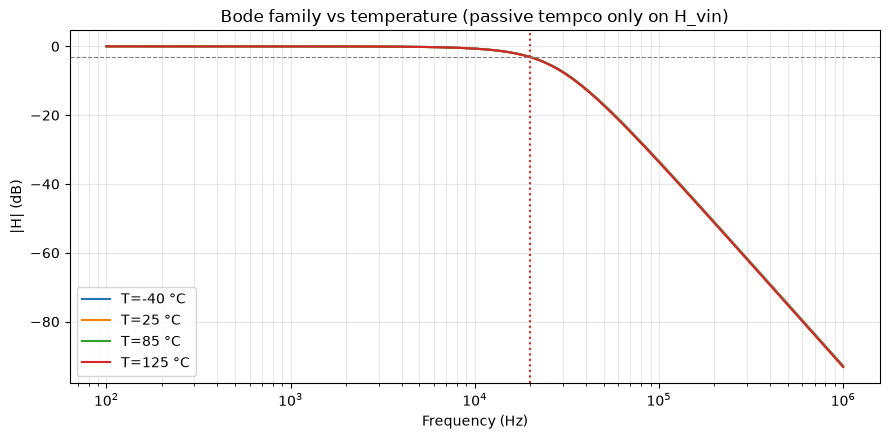

In [3]:
# Bode family at selected temperatures
from opamp_design.analysis import bode, frequency_grid
f = frequency_grid(100, 1e6, 201)
fig, ax = plt.subplots(figsize=(9, 4.5))
for T in [-40, 25, 85, 125]:
    pt = p.scaled_at_temp(T)
    br = bode(pt, f_hz=f)
    ax.semilogx(br.f_hz, br.mag_db, label=f"T={T} °C")
ax.axhline(-3, color="gray", ls="--", lw=0.8)
ax.axvline(p.op.f_design_hz, color="C3", ls=":")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("|H| (dB)")
ax.set_title("Bode family vs temperature (passive tempco only on H_vin)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "06_bode_vs_temp.png", dpi=150)
plt.show()

,temp_c,fc_spice_hz,passband_gain_spice
0,-40,19870.306034,0.999999
1,25,19762.009301,0.999999
2,85,19663.929129,0.999999
3,125,19599.524147,0.999999


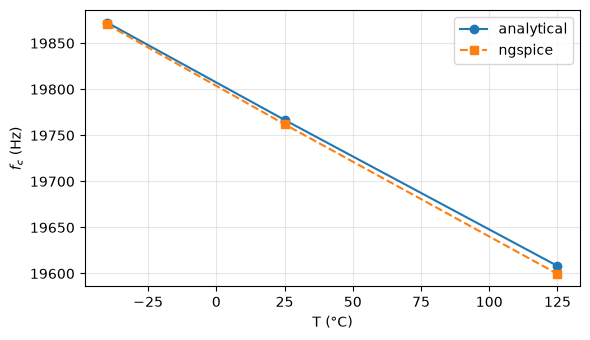

In [4]:
# Optional coarse SPICE temp sweep (ideal + scaled passives)
try:
    temps = [-40, 25, 85, 125]
    sts = spice_temp_sweep(
        p, temps_c=temps,
        workdir=ROOT / "results" / "ngspice_temp",
        root=ROOT, opamp_model="ideal",
    )
    display(sts.frame)
    merged = ts.frame[ts.frame.temp_c.isin(temps)].merge(sts.frame, on="temp_c")
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(merged.temp_c, merged.fc_hz, "o-", label="analytical")
    ax.plot(merged.temp_c, merged.fc_spice_hz, "s--", label="ngspice")
    ax.set_xlabel("T (°C)")
    ax.set_ylabel(r"$f_c$ (Hz)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG / "06_fc_temp_spice_vs_an.png", dpi=150)
    plt.show()
except Exception as e:
    print("SPICE temp sweep skipped/failed:", e)